# Assignment 1 2AMM10 2025-2026

## Group: [DL group]
### Member 1: [Hannes Janmaat 1548999]
### Member 2: [Benjamin Softic 1573608]
### Member 3: [Deins Kovalcuks 1847031]

## Task 1

Dataset and visualization

In [1]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else:
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([item_dd, frame_slider, output]))

100%|██████████| 5.95G/5.95G [00:54<00:00, 117MB/s]

Extracting files...


In [2]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.RandomAffine(degrees=8, translate=(0.04, 0.04), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
eval_transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
train_data = AppleDataset(subset="train", transform=train_transform)
test_data = AppleDataset(subset="test", transform=eval_transform)
support_new_data = AppleDataset(subset="train", transform=eval_transform, class_subset="new")
test_new_data = AppleDataset(subset="test", transform=eval_transform, class_subset="new")

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EmbeddingNet(nn.Module):
    def __init__(self):
        super(EmbeddingNet, self).__init__()

        self.front_layer = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=5, stride=5),
            nn.Conv2d(64, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=5, stride=1),
        )

        self.last_layer = nn.Linear(128, 32)

    def forward(self, x):
        x = self.front_layer(x)
        x = torch.flatten(x, start_dim=1)
        x = self.last_layer(x)
        x = F.normalize(x, p=2, dim=1)
        return x

    def get_embedding(self, x):
        return self.forward(x)

In [4]:
from torch.utils.data.sampler import BatchSampler
import numpy as np
class BalancedBatchSampler(BatchSampler):
    def __init__(self, labels, n_classes, n_samples):
        self.labels = labels
        self.labels_set = list(set(self.labels))
        self.label_to_indices = {label: np.where(  np.array(self.labels) == label)[0]
                                 for label in self.labels_set}
        for l in self.labels_set:
            np.random.shuffle(self.label_to_indices[l])
        self.used_label_indices_count = {label: 0 for label in self.labels_set}
        self.count = 0
        self.n_classes = n_classes
        self.n_samples = n_samples
        self.n_dataset = len(self.labels)
        self.batch_size = self.n_samples * self.n_classes

    def __iter__(self):
        self.count = 0
        while self.count + self.batch_size < self.n_dataset:
            classes = np.random.choice(self.labels_set, self.n_classes, replace=False)
            indices = []
            for class_ in classes:
                indices.extend(self.label_to_indices[class_][
                               self.used_label_indices_count[class_]:self.used_label_indices_count[
                                                                         class_] + self.n_samples])
                self.used_label_indices_count[class_] += self.n_samples
                if self.used_label_indices_count[class_] + self.n_samples > len(self.label_to_indices[class_]):
                    np.random.shuffle(self.label_to_indices[class_])
                    self.used_label_indices_count[class_] = 0
            yield indices
            self.count += self.n_classes * self.n_samples

    def __len__(self):
        return self.n_dataset // self.batch_size

In [5]:
train_batch_sampler = BalancedBatchSampler(train_data.targets, n_classes=10, n_samples=6)

triplets_train_loader = torch.utils.data.DataLoader(train_data, batch_sampler=train_batch_sampler)

In [6]:
from itertools import combinations

def pdist(vectors):
    distance_matrix = -2 * vectors.mm(torch.t(vectors)) + vectors.pow(2).sum(dim=1).view(1, -1) + vectors.pow(2).sum(
        dim=1).view(-1, 1)
    return distance_matrix

class Informative_Negative_TripletSelector():

    def __init__(self, margin):
        super(Informative_Negative_TripletSelector, self).__init__()

        self.margin = margin

   # Our goal is to mining informative triplets.
    def informative_negative(self, loss_values):

        informative_negative = np.where(loss_values > 0)[0]
        return np.random.choice(informative_negative) if len(informative_negative) > 0 else None


    def get_triplets(self, embeddings, labels):

        if torch.cuda.is_available()==False:
            embeddings = embeddings.cpu()
        distance_matrix = pdist(embeddings)
        distance_matrix = distance_matrix.cpu()

        labels = labels.cpu().data.numpy()
        triplets = []

        for label in set(labels):
            label_mask = (labels == label)
            label_indices = np.where(label_mask)[0]
            if len(label_indices) < 2:
                continue
            negative_indices = np.where(np.logical_not(label_mask))[0]
            anchor_positives = list(combinations(label_indices, 2))  # All anchor-positive pairs
            anchor_positives = np.array(anchor_positives)


            ap_distances = distance_matrix[anchor_positives[:, 0], anchor_positives[:, 1]]
            for anchor_positive, ap_distance in zip(anchor_positives, ap_distances):
                loss_values = ap_distance - distance_matrix[torch.LongTensor(np.array([anchor_positive[0]])), torch.LongTensor(negative_indices)] + self.margin
                loss_values = loss_values.data.cpu().numpy()

                informative_negative = self.informative_negative(loss_values)
                if informative_negative is not None:
                    informative_negative = negative_indices[informative_negative]
                    triplets.append([anchor_positive[0], anchor_positive[1], informative_negative])

        if len(triplets) == 0:
            triplets.append([anchor_positive[0], anchor_positive[1], negative_indices[0]])

        triplets = np.array(triplets)

        return torch.LongTensor(triplets)

In [7]:
class TripletLoss(nn.Module):
    def __init__(self, margin, triplet_selector):
        super(TripletLoss, self).__init__()
        self.margin = margin
        self.triplet_selector = triplet_selector

    def forward(self, embeddings, target):

        triplets = self.triplet_selector.get_triplets(embeddings, target)
        # print("triplets: ", triplets[0].shape)

        if embeddings.is_cuda:
            triplets = triplets.cuda()


        anchor_idx= triplets[:, 0]
        positive_idx= triplets[:, 1]
        negative_idx= triplets[:, 2]

        anchors = embeddings[anchor_idx]
        positives = embeddings[positive_idx]
        negatives = embeddings[negative_idx]

        distance_vectors_to_positive = anchors - positives
        distance_vectors_to_neagtive = anchors - negatives
        norm_squared_of_distance_vectors_to_positive = (distance_vectors_to_positive ** 2).sum(dim=1)
        norm_squared_of_distance_vectors_to_negative = (distance_vectors_to_neagtive ** 2).sum(dim=1)

        margin_vector = torch.tensor([self.margin for i in range(anchors.shape[0])],
    device=device)
        delta_vector = margin_vector + norm_squared_of_distance_vectors_to_positive - norm_squared_of_distance_vectors_to_negative

        zeros = torch.zeros((anchors.shape[0])).to(device)
        zeros_delta = torch.cat([zeros.unsqueeze(1), delta_vector.unsqueeze(1)], dim = 1)
        losses = torch.max(zeros_delta, dim=1).values

        return losses.mean()

In [8]:
import numpy as np
from tqdm import tqdm


class Trainer():
    def __init__(self,
                 model: torch.nn.Module,
                 device: torch.device,
                 criterion: torch.nn.Module,
                 optimizer: torch.optim.Optimizer,
                 training_DataLoader: torch.utils.data.Dataset,
                 epochs: int
                 ):

        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.training_DataLoader = training_DataLoader
        self.device = device
        self.epochs = epochs

    def run_trainer(self):
        for epoch in tqdm(range(self.epochs)):
            self.model.train()
            train_losses=[]
            for batch in self.training_DataLoader:
                x,y=batch
                input, target = x.to(self.device), y.to(self.device)
                self.optimizer.zero_grad()
                out = self.model(input)
                loss = self.criterion(out, target)
                loss_value = loss.item()
                train_losses.append(loss_value)
                loss.backward()
                self.optimizer.step()

            print(f'EPOCH: {epoch+1:0>{len(str(self.epochs))}}/{self.epochs}', end=' ')
            print(f'LOSS: {np.mean(train_losses):.4f}',end=' ')

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device=torch.device('cpu')

mined_embedding_net = EmbeddingNet()
mined_model = mined_embedding_net.to(device)
margin=.5
criterion = TripletLoss(margin,  Informative_Negative_TripletSelector(margin))
optimizer = torch.optim.Adam(mined_model.parameters(), lr=1e-3)
trainer = Trainer(model=mined_model,
                  device=device,
                  criterion=criterion,
                  optimizer=optimizer,
                  training_DataLoader=triplets_train_loader,
                  epochs=20,
                  )
trainer.run_trainer()

  5%|▌         | 1/20 [00:18<05:42, 18.02s/it]

EPOCH: 01/20 LOSS: 0.3012 

 10%|█         | 2/20 [00:35<05:23, 17.98s/it]

EPOCH: 02/20 LOSS: 0.2216 

 15%|█▌        | 3/20 [00:54<05:10, 18.28s/it]

...

EPOCH: 18/20 LOSS: 0.0949 

 95%|█████████▌| 19/20 [05:51<00:18, 18.34s/it]

EPOCH: 19/20 LOSS: 0.1003 

100%|██████████| 20/20 [06:10<00:00, 18.53s/it]

EPOCH: 20/20 LOSS: 0.0775 

In [9]:
def dist(centroids, embedding):
    result = []

    for label, centroid in centroids.items():
        distance = ((centroid - embedding) ** 2).sum()
        result.append((label, distance))

    result.sort(key=lambda x: x[1])
    return result

def compute_centroids(dataset):
    mined_model.eval()
    labels = np.array(dataset.targets)

    clusters = {}
    for label in np.unique(labels):
        clusters[label] = []
    for ix, label in enumerate(labels):
        img, _ = dataset[ix]
        img = img.unsqueeze(0).to(device)
        with torch.no_grad():
            embedding = mined_model(img).squeeze(0).cpu()
        clusters[label].append(embedding)

    centroids = {}
    for label, cluster in clusters.items():
        cluster = torch.stack(cluster)
        centroid = cluster.mean(dim=0)
        centroid = F.normalize(centroid.unsqueeze(0), p=2, dim=1).squeeze(0)
        centroids[label] = centroid
    return centroids

def nearest_centroid_label(centroids, embedding):
    distances = dist(centroids, embedding)
    return distances[0][0]

def evaluate_nearest_centroid(support_dataset, test_dataset):
    mined_model.eval()
    centroids = compute_centroids(support_dataset)
    correctly_classified = 0
    for x, y in test_dataset:
        input = x.unsqueeze(0).to(device)
        with torch.no_grad():
            embedding = mined_model(input).squeeze(0).cpu()
        prediction = nearest_centroid_label(centroids, embedding)
        if prediction == y:
            correctly_classified += 1
    accuracy = correctly_classified / len(test_dataset)
    return accuracy

In [ ]:
seen_accuracy = evaluate_nearest_centroid(support_dataset=train_data, test_dataset=test_data)
unseen_accuracy = evaluate_nearest_centroid(support_dataset=support_new_data, test_dataset=test_new_data)

print("Seen-item test accuracy: ", seen_accuracy)
print("Unseen-item test accuracy: ", unseen_accuracy)

Seen-item test accuracy:  0.9479843953185956
Unseen-item test accuracy:  0.8693982074263764


In [ ]:
torch.save(mined_model.state_dict(), "model_weights.pth")
print(os.getcwd())

## Task 2

In [10]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0])

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)

        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

family_dd.observe(update_items, names="value")
item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.RandomAffine(degrees=8, translate=(0.04, 0.04), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
eval_transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = GardenDataset(subset="train", transform=eval_transform)
train_data_aug = GardenDataset(subset="train", transform=train_transform)

# scenario 1
test_data = GardenDataset(subset="test", transform=eval_transform)

# scenario 2
train_data_family = GardenDataset(subset="train", transform=eval_transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=eval_transform, class_level="family")

# scenario 3
support_all_data = GardenDataset(subset="train", transform=eval_transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=eval_transform, item_subset="new")

# scenario 4
support_all_data_family = GardenDataset(subset="train", transform=eval_transform, family_subset="all", class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=eval_transform, family_subset="new", class_level="family")


In [12]:
train_batch_sampler = BalancedBatchSampler(train_data_aug.targets, n_classes=30, n_samples=4)

triplets_train_loader = torch.utils.data.DataLoader(train_data_aug, batch_sampler=train_batch_sampler)

In [13]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device=torch.device('cpu')


mined_embedding_net = EmbeddingNet()

mined_model = mined_embedding_net.to(device)
margin=0.5
criterion = TripletLoss(margin,  Informative_Negative_TripletSelector(margin))
optimizer = torch.optim.Adam(mined_model.parameters(), lr=1e-3)
trainer = Trainer(model=mined_model,
                  device=device,
                  criterion=criterion,
                  optimizer=optimizer,
                  training_DataLoader=triplets_train_loader,
                  epochs= 5,
                  )
trainer.run_trainer()

 20%|██        | 1/5 [02:12<08:50, 132.59s/it]

EPOCH: 1/5 LOSS: 0.2654 

 40%|████      | 2/5 [04:13<06:17, 125.97s/it]

EPOCH: 2/5 LOSS: 0.2144 

 60%|██████    | 3/5 [06:14<04:06, 123.46s/it]

EPOCH: 3/5 LOSS: 0.2059 

 80%|████████  | 4/5 [08:15<02:02, 122.48s/it]

EPOCH: 4/5 LOSS: 0.1983 

100%|██████████| 5/5 [10:15<00:00, 123.18s/it]

EPOCH: 5/5 LOSS: 0.1888 

In [14]:
def compute_embeddings_and_labels(dataset):
    mined_model.eval()
    loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=False)

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            embeddings = mined_model(x_batch)

            all_embeddings.append(embeddings)
            all_labels.append(y_batch.to(device))

    return torch.cat(all_embeddings), torch.cat(all_labels)


def predict_knn_labels(support_dataset, test_dataset, k=5):
    support_embeddings, support_labels = compute_embeddings_and_labels(support_dataset)

    y_true = []
    y_pred = []

    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

    mined_model.eval()

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            test_embeddings = mined_model(x_batch)

            # Pairwise distances between each test embedding and each support embedding
            distances = torch.cdist(test_embeddings, support_embeddings)

            # For each test image, find the k nearest support images
            nearest_indices = distances.topk(k=k, dim=1, largest=False).indices

            # Look up the labels of those nearest support images
            nearest_labels = support_labels[nearest_indices]

            # Majority vote among the k nearest labels
            predictions = torch.mode(nearest_labels, dim=1).values

            y_true.append(y_batch)
            y_pred.append(predictions)

    return torch.cat(y_true), torch.cat(y_pred)


def evaluate_knn(support_dataset, test_dataset, k=5):
    y_true, y_pred = predict_knn_labels(support_dataset, test_dataset, k)
    accuracy = (y_true == y_pred).float().mean().item()
    return accuracy

In [15]:
acc_s1 = evaluate_nearest_centroid(support_dataset=train_data, test_dataset=test_data)
print("Scenario 1 test accuracy: ", acc_s1)

Scenario 1 test accuracy:  0.9656143899443762


In [16]:
acc_s2_centroid = evaluate_nearest_centroid(
    support_dataset=train_data_family,
    test_dataset=test_data_family
)

acc_s2_knn = evaluate_knn(
    support_dataset=train_data_family,
    test_dataset=test_data_family,
    k=5
)

print("Scenario 2 centroid accuracy:", acc_s2_centroid)
print("Scenario 2 KNN accuracy:", acc_s2_knn)

Scenario 2 centroid accuracy: 0.7609622191721448
Scenario 2 KNN accuracy: 0.9999277591705322


In [17]:
acc_s3 = evaluate_nearest_centroid(support_dataset=support_all_data, test_dataset=test_new_data)
print("Scenario 3 test accuracy: ", acc_s3)

Scenario 3 test accuracy:  0.9355657026889903


In [18]:
acc_s4_centroid = evaluate_nearest_centroid(
    support_dataset=support_all_data_family,
    test_dataset=test_new_data_family
)

acc_s4_knn = evaluate_knn(
    support_dataset=support_all_data_family,
    test_dataset=test_new_data_family,
    k=5
)

print("Scenario 4 centroid accuracy:", acc_s4_centroid)
print("Scenario 4 KNN accuracy:", acc_s4_knn)

Scenario 4 centroid accuracy: 0.9872581406323737
Scenario 4 KNN accuracy: 0.9995280504226685


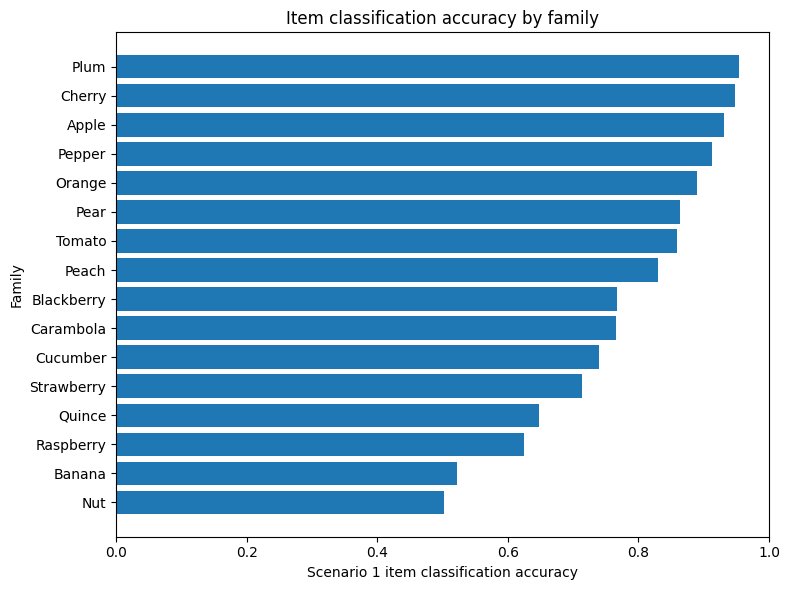

{'Apple': 0.9305301645338209, 'Banana': 0.5214723926380368, 'Blackberry': 0.7678275290215588, 'Carambola': 0.7656903765690377, 'Cherry': 0.9483870967741935, 'Cucumber': 0.740011580775912, 'Nut': 0.5015576323987538, 'Orange': 0.8900900900900901, 'Peach': 0.8298465829846583, 'Pear': 0.863948694457169, 'Pepper': 0.9123711340206185, 'Plum': 0.9541484716157205, 'Quince': 0.6470588235294118, 'Raspberry': 0.6240458015267175, 'Strawberry': 0.7129337539432177, 'Tomato': 0.8597091531223268}


In [19]:
from collections import defaultdict
import matplotlib.pyplot as plt

def item_accuracy_by_family(support_dataset, test_dataset):
    mined_model.eval()

    centroids = compute_centroids(support_dataset)

    centroids = {
        label: centroid.to(device)
        for label, centroid in centroids.items()
    }

    idx_to_family = {
        idx: family
        for family, idx in test_dataset.family_to_idx.items()
    }

    family_correct = defaultdict(int)
    family_total = defaultdict(int)

    loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

    start_idx = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            batch_size = y_batch.size(0)

            family_ids = test_dataset.targets_family[start_idx:start_idx + batch_size]
            start_idx += batch_size

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            embeddings = mined_model(x_batch)
            predictions = nearest_centroid_label(centroids, embeddings)

            correct = predictions == y_batch

            for family_id, is_correct in zip(family_ids, correct.cpu()):
                family_name = idx_to_family[family_id]
                family_correct[family_name] += int(is_correct)
                family_total[family_name] += 1

    family_accuracy = {
        family: family_correct[family] / family_total[family]
        for family in family_total
    }

    return family_accuracy


family_accuracy = item_accuracy_by_family(
    support_dataset = train_data,
    test_dataset=test_data
)

families = sorted(family_accuracy, key=family_accuracy.get)
accuracies = [family_accuracy[family] for family in families]

plt.figure(figsize=(8, 6))
plt.barh(families, accuracies)
plt.xlim(0, 1)
plt.xlabel("Scenario 1 item classification accuracy")
plt.ylabel("Family")
plt.title("Item classification accuracy by family")
plt.tight_layout()
plt.show()

print(family_accuracy)

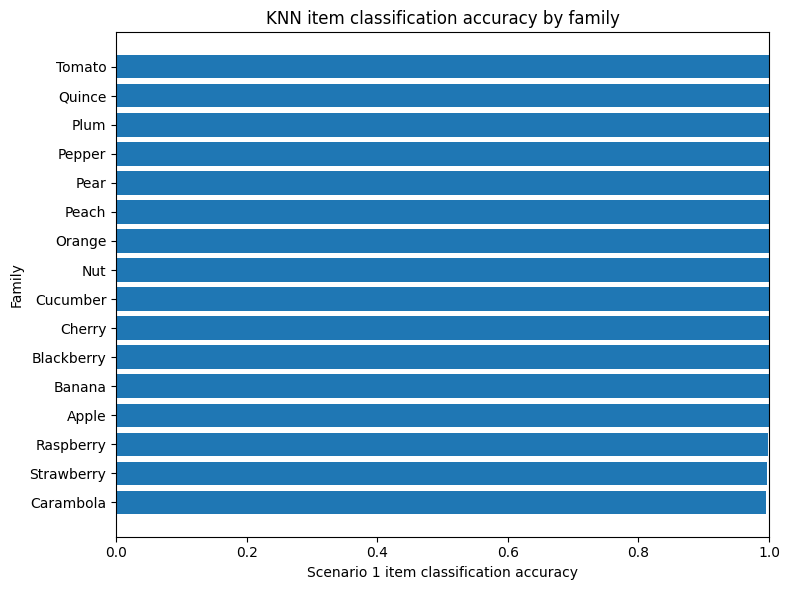

{'Apple': 1.0, 'Banana': 1.0, 'Blackberry': 1.0, 'Carambola': 0.99581589958159, 'Cherry': 1.0, 'Cucumber': 1.0, 'Nut': 1.0, 'Orange': 1.0, 'Peach': 1.0, 'Pear': 1.0, 'Pepper': 1.0, 'Plum': 1.0, 'Quince': 1.0, 'Raspberry': 0.9980916030534351, 'Strawberry': 0.9968454258675079, 'Tomato': 1.0}


In [20]:
def compute_support_embeddings_and_labels(support_dataset):
    mined_model.eval()

    loader = torch.utils.data.DataLoader(
        support_dataset,
        batch_size=128,
        shuffle=False
    )

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)

            embeddings = mined_model(x_batch)

            all_embeddings.append(embeddings)
            all_labels.append(y_batch.to(device))

    support_embeddings = torch.cat(all_embeddings)
    support_labels = torch.cat(all_labels)

    return support_embeddings, support_labels


def item_accuracy_by_family_knn(support_dataset, test_dataset, k=5):
    mined_model.eval()

    support_embeddings, support_labels = compute_support_embeddings_and_labels(
        support_dataset
    )

    idx_to_family = {
        idx: family
        for family, idx in test_dataset.family_to_idx.items()
    }

    family_correct = defaultdict(int)
    family_total = defaultdict(int)

    loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=128,
        shuffle=False
    )

    start_idx = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            batch_size = y_batch.size(0)

            family_ids = test_dataset.targets_family[start_idx:start_idx + batch_size]
            start_idx += batch_size

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            test_embeddings = mined_model(x_batch)

            distances = torch.cdist(test_embeddings, support_embeddings)

            nearest_indices = distances.topk(
                k=k,
                dim=1,
                largest=False
            ).indices

            nearest_labels = support_labels[nearest_indices]

            predictions = torch.mode(nearest_labels, dim=1).values

            correct = predictions == y_batch

            for family_id, is_correct in zip(family_ids, correct.cpu()):
                family_name = idx_to_family[family_id]
                family_correct[family_name] += int(is_correct)
                family_total[family_name] += 1

    family_accuracy = {
        family: family_correct[family] / family_total[family]
        for family in family_total
    }

    return family_accuracy


family_accuracy = item_accuracy_by_family_knn(
    support_dataset=train_data,
    test_dataset=test_data,
    k=5
)

families = sorted(family_accuracy, key=family_accuracy.get)
accuracies = [family_accuracy[family] for family in families]

plt.figure(figsize=(8, 6))
plt.barh(families, accuracies)
plt.xlim(0, 1)
plt.xlabel("Scenario 1 item classification accuracy")
plt.ylabel("Family")
plt.title("KNN item classification accuracy by family")
plt.tight_layout()
plt.show()

print(family_accuracy)

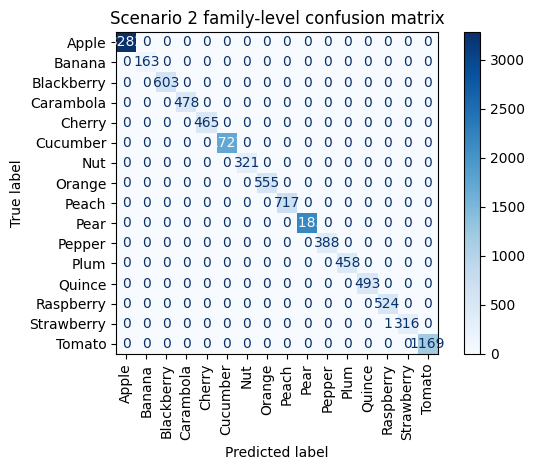

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true_s2, y_pred_s2 = predict_knn_labels(
    support_dataset=train_data_family,
    test_dataset=test_data_family,
    k=5
)

family_labels = [
    train_data_family.family_to_idx[family]
    for family in train_data_family.families
]

cm = confusion_matrix(
    y_true_s2.cpu().numpy(),
    y_pred_s2.cpu().numpy(),
    labels=family_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data_family.families
)

disp.plot(cmap="Blues", values_format="d")
plt.xticks(rotation=90)
plt.title("Scenario 2 family-level confusion matrix")
plt.tight_layout()
plt.show()

## Task 3

In [22]:
train_data_both = GardenDataset(
    class_level="both",
    transform=train_transform,
    subset="train",
    family_subset="main",
    item_subset="main"
)

test_data_both = GardenDataset(
    class_level="both",
    transform=eval_transform,
    subset="test",
    family_subset="main",
    item_subset="main"
)

train_data_t3 = GardenDataset(
    class_level="item",
    transform=eval_transform,
    subset="train",
    family_subset="main",
    item_subset="main"
)

test_data_t3 = GardenDataset(
    class_level="item",
    transform=eval_transform,
    subset="test",
    family_subset="main",
    item_subset="main"
)

support_all_data_t3 = GardenDataset(
    class_level="item",
    transform=eval_transform,
    subset="train",
    family_subset="main",
    item_subset="all"
)

test_new_data_t3 = GardenDataset(
    class_level="item",
    transform=eval_transform,
    subset="test",
    family_subset="main",
    item_subset="new"
)

train_data_family_t3 = GardenDataset(
    class_level="family",
    transform=eval_transform,
    subset="train",
    family_subset="main",
    item_subset="main"
)

test_data_family_t3 = GardenDataset(
    class_level="family",
    transform=eval_transform,
    subset="test",
    family_subset="main",
    item_subset="main"
)

support_all_data_family_t3 = GardenDataset(
    class_level="family",
    transform=eval_transform,
    subset="train",
    family_subset="all",
    item_subset="main"
)

test_new_data_family_t3 = GardenDataset(
    class_level="family",
    transform=eval_transform,
    subset="test",
    family_subset="new",
    item_subset="main"
)

Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.
Using Colab cache for faster access to the 'fruits' dataset.


In [23]:
train_batch_sampler_t3 = BalancedBatchSampler(
    train_data_both.targets_item,
    n_classes=30,
    n_samples=4
)

combined_train_loader = torch.utils.data.DataLoader(
    train_data_both,
    batch_sampler=train_batch_sampler_t3
)

In [24]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


combined_embedding_net = EmbeddingNet()
combined_model = combined_embedding_net.to(device)

margin = 0.5
family_loss_weight = 0.3

item_criterion = TripletLoss(
    margin,
    Informative_Negative_TripletSelector(margin)
)

family_criterion = TripletLoss(
    margin,
    Informative_Negative_TripletSelector(margin)
)

optimizer = torch.optim.Adam(combined_model.parameters(), lr=1e-3)

epochs = 5

for epoch in range(epochs):
    combined_model.train()

    total_loss_sum = 0
    item_loss_sum = 0
    family_loss_sum = 0
    num_batches = 0

    for x_batch, y_family, y_item in combined_train_loader:
        x_batch = x_batch.to(device)
        y_family = y_family.to(device)
        y_item = y_item.to(device)

        optimizer.zero_grad()

        embeddings = combined_model(x_batch)

        item_loss = item_criterion(embeddings, y_item)
        family_loss = family_criterion(embeddings, y_family)

        loss = item_loss + family_loss_weight * family_loss

        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        item_loss_sum += item_loss.item()
        family_loss_sum += family_loss.item()
        num_batches += 1

    print(
        "Epoch:",
        epoch + 1,
        "Total loss:",
        total_loss_sum / num_batches,
        "Item loss:",
        item_loss_sum / num_batches,
        "Family loss:",
        family_loss_sum / num_batches
    )

Epoch: 1 Total loss: 0.4057651546986207 Item loss: 0.25856157644935274 Family loss: 0.49067857265472414
Epoch: 2 Total loss: 0.3392304722381675 Item loss: 0.22533237344544868 Family loss: 0.37966031276661416
Epoch: 3 Total loss: 0.31393145562514013 Item loss: 0.21119045913219453 Family loss: 0.34246997619452685
Epoch: 4 Total loss: 0.2974025099173836 Item loss: 0.20340829251900963 Family loss: 0.3133140468079111
Epoch: 5 Total loss: 0.2878626204703165 Item loss: 0.1995046697880911 Family loss: 0.29452649050432705


In [25]:
from collections import defaultdict
from torch.utils.data import DataLoader
import torch
import torch.nn.functional as F

def compute_centroids_for_model(model, dataset):
    model.eval()

    labels = np.array(dataset.targets)

    clusters = {}
    for label in np.unique(labels):
        clusters[label] = []

    for ix, label in enumerate(labels):
        img, _ = dataset[ix]
        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            embedding = model(img).squeeze(0).cpu()

        clusters[label].append(embedding)

    centroids = {}

    for label, cluster in clusters.items():
        cluster = torch.stack(cluster)
        centroid = cluster.mean(dim=0)
        centroid = F.normalize(centroid.unsqueeze(0), p=2, dim=1).squeeze(0)
        centroids[label] = centroid.to(device)

    return centroids


def nearest_centroid_label_for_model(centroids, embedding):
    result = []

    for label, centroid in centroids.items():
        distance = ((centroid - embedding) ** 2).sum()
        result.append((label, distance))

    result.sort(key=lambda x: x[1])
    return result[0][0]


def nearest_centroid_labels_for_model(centroids, embeddings):
    predictions = []

    for embedding in embeddings:
        prediction = nearest_centroid_label_for_model(centroids, embedding)
        predictions.append(prediction)

    return torch.tensor(predictions, device=device)


def evaluate_nearest_centroid_for_model(model, support_dataset, test_dataset):
    model.eval()

    centroids = compute_centroids_for_model(model, support_dataset)

    correctly_classified = 0

    for x, y in test_dataset:
        input = x.unsqueeze(0).to(device)

        with torch.no_grad():
            embedding = model(input).squeeze(0)

        prediction = nearest_centroid_label_for_model(centroids, embedding)

        if prediction == y:
            correctly_classified += 1

    accuracy = correctly_classified / len(test_dataset)

    return accuracy

In [26]:
acc_s1_t3 = evaluate_nearest_centroid_for_model(
    model=combined_model,
    support_dataset=train_data_t3,
    test_dataset=test_data_t3
)

print("Task 3 Scenario 1 test accuracy:", acc_s1_t3)


acc_s2_t3 = evaluate_nearest_centroid_for_model(
    model=combined_model,
    support_dataset=train_data_family_t3,
    test_dataset=test_data_family_t3
)

print("Task 3 Scenario 2 test accuracy:", acc_s2_t3)


acc_s3_t3 = evaluate_nearest_centroid_for_model(
    model=combined_model,
    support_dataset=support_all_data_t3,
    test_dataset=test_new_data_t3
)

print("Task 3 Scenario 3 test accuracy:", acc_s3_t3)


acc_s4_t3 = evaluate_nearest_centroid_for_model(
    model=combined_model,
    support_dataset=support_all_data_family_t3,
    test_dataset=test_new_data_family_t3
)

print("Task 3 Scenario 4 test accuracy:", acc_s4_t3)

Task 3 Scenario 1 test accuracy: 0.9510944159502998
Task 3 Scenario 2 test accuracy: 0.9578848515495196
Task 3 Scenario 3 test accuracy: 0.9173008625063419
Task 3 Scenario 4 test accuracy: 0.9943369513921662


In [27]:
print("Scenario 1")
print("Task 2:", acc_s1)
print("Task 3:", acc_s1_t3)
print()

print("Scenario 2")
print("Task 2 C:", acc_s2_centroid)
print("Task 2 K:", acc_s2_knn)
print("Task 3:", acc_s2_t3)
print()

print("Scenario 3")
print("Task 2:", acc_s3)
print("Task 3:", acc_s3_t3)
print()

print("Scenario 4")
print("Task 2 C:", acc_s4_centroid)
print("Task 2 K:", acc_s4_knn)
print("Task 3:", acc_s4_t3)

Scenario 1
Task 2: 0.9656143899443762
Task 3: 0.9510944159502998

Scenario 2
Task 2 C: 0.7609622191721448
Task 2 K: 0.9999277591705322
Task 3: 0.9578848515495196

Scenario 3
Task 2: 0.9355657026889903
Task 3: 0.9173008625063419

Scenario 4
Task 2 C: 0.9872581406323737
Task 2 K: 0.9995280504226685
Task 3: 0.9943369513921662


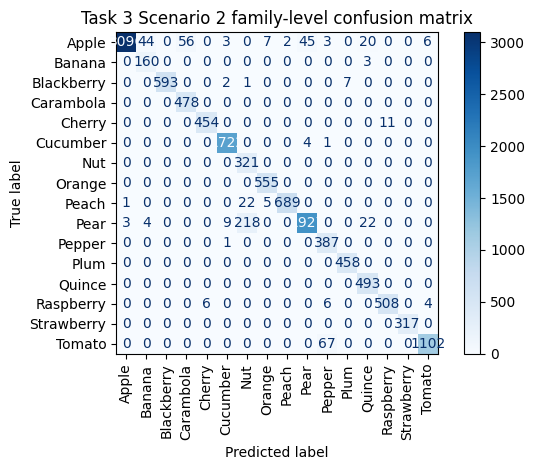

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def get_predictions_nearest_centroid_for_model(model, support_dataset, test_dataset):
    model.eval()

    centroids = compute_centroids_for_model(model, support_dataset)

    y_true = []
    y_pred = []

    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            embeddings = model(x_batch)
            predictions = nearest_centroid_labels_for_model(centroids, embeddings)

            y_true.append(y_batch)
            y_pred.append(predictions)

    return torch.cat(y_true), torch.cat(y_pred)


y_true_s2_t3, y_pred_s2_t3 = get_predictions_nearest_centroid_for_model(
    model=combined_model,
    support_dataset=train_data_family_t3,
    test_dataset=test_data_family_t3
)

family_labels_t3 = [
    train_data_family_t3.family_to_idx[family]
    for family in train_data_family_t3.families
]

cm_t3 = confusion_matrix(
    y_true_s2_t3.cpu().numpy(),
    y_pred_s2_t3.cpu().numpy(),
    labels=family_labels_t3
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_t3,
    display_labels=train_data_family_t3.families
)

disp.plot(cmap="Blues", values_format="d")
plt.xticks(rotation=90)
plt.title("Task 3 Scenario 2 family-level confusion matrix")
plt.tight_layout()
plt.show()

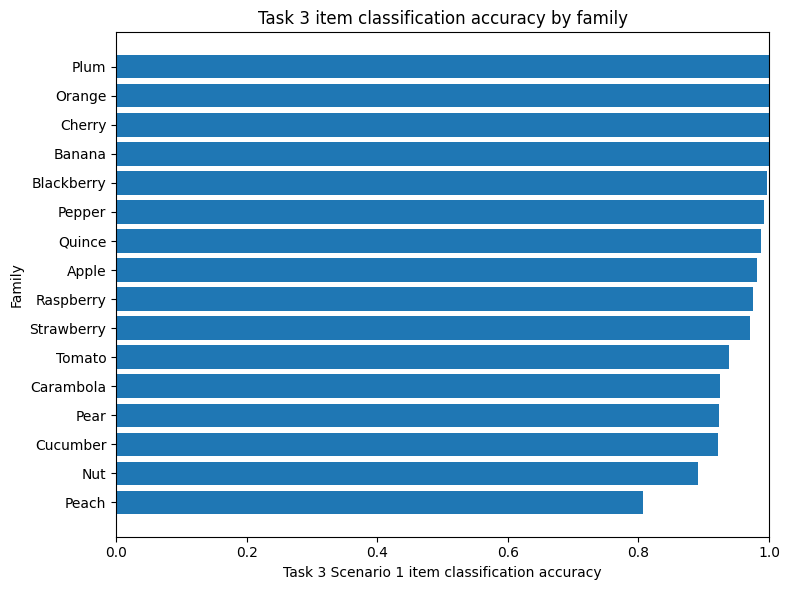

{'Apple': 0.9817184643510055, 'Banana': 1.0, 'Blackberry': 0.9966832504145937, 'Carambola': 0.9246861924686193, 'Cherry': 1.0, 'Cucumber': 0.9212507237984945, 'Nut': 0.8909657320872274, 'Orange': 1.0, 'Peach': 0.8075313807531381, 'Pear': 0.9234997709573981, 'Pepper': 0.9922680412371134, 'Plum': 1.0, 'Quince': 0.9878296146044625, 'Raspberry': 0.9751908396946565, 'Strawberry': 0.9716088328075709, 'Tomato': 0.9384088964927289}


In [29]:
def item_accuracy_by_family_for_model(model, support_dataset, test_dataset):
    model.eval()

    centroids = compute_centroids_for_model(model, support_dataset)

    idx_to_family = {
        idx: family
        for family, idx in test_dataset.family_to_idx.items()
    }

    family_correct = defaultdict(int)
    family_total = defaultdict(int)

    loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    start_idx = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            batch_size = y_batch.size(0)

            family_ids = test_dataset.targets_family[start_idx:start_idx + batch_size]
            start_idx += batch_size

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            embeddings = model(x_batch)
            predictions = nearest_centroid_labels_for_model(centroids, embeddings)

            correct = predictions == y_batch

            for family_id, is_correct in zip(family_ids, correct.cpu()):
                family_name = idx_to_family[family_id]
                family_correct[family_name] += int(is_correct)
                family_total[family_name] += 1

    family_accuracy = {
        family: family_correct[family] / family_total[family]
        for family in family_total
    }

    return family_accuracy


family_accuracy_t3 = item_accuracy_by_family_for_model(
    model=combined_model,
    support_dataset=train_data_t3,
    test_dataset=test_data_t3
)

families_t3 = sorted(family_accuracy_t3, key=family_accuracy_t3.get)
accuracies_t3 = [family_accuracy_t3[family] for family in families_t3]

plt.figure(figsize=(8, 6))
plt.barh(families_t3, accuracies_t3)
plt.xlim(0, 1)
plt.xlabel("Task 3 Scenario 1 item classification accuracy")
plt.ylabel("Family")
plt.title("Task 3 item classification accuracy by family")
plt.tight_layout()
plt.show()

print(family_accuracy_t3)

## Task 4

In [ ]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).

    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    transform = transforms.Compose([
        eval_transform,
        BlackoutPixels(fraction=fraction)
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here
# we could threshold on the distance to the closest training sample. if image is similar to a training example it will be closer and if it is dissimilar, it will be farther away.

train_emb3, train_lbl3, train_family_labels3

def anomaly_detector(x, threshold, supports):
    # x shape = (B, C, H, W)

    model3.eval()

    with torch.no_grad():
        embeddings = model3(x).cpu().numpy()

    # print(supports)

    # supports shape: (N_support, D)
    distances = cdist(embeddings, supports)
    # print(distances)

    nearest_support_distances = distances.min(axis=1)

    # print(nearest_support_distances)

    predictions = nearest_support_distances >= threshold

    return predictions


def proportion_of_positives(test_loader, support_set, threshold = 0.1):
  n_postitives = 0
  total_nr = 0

  for x_batch, y_batch in test_loader:
    x_batch = x_batch.to(device)
    n_postitives = n_postitives + anomaly_detector(x_batch, threshold, support_set).sum()
    total_nr = total_nr + len(x_batch)

  proportion_of_positives = n_postitives / total_nr
  return proportion_of_positives

In [ ]:
proportion_of_postives_test_set = proportion_of_positives(test_loader = test_loader, support_set = train_emb3)
print("proportion_of_postives_test_set: ", proportion_of_postives_test_set)
anomaly_1_loader = torch.utils.data.DataLoader(get_anomaly_dataset(0.01), batch_size=64, shuffle=False)
proportion_of_postives_anomaly_1 = proportion_of_positives(test_loader = anomaly_1_loader, support_set = train_emb3)
print("proportion_of_postives_anomaly_1: ", proportion_of_postives_anomaly_1)
anomaly_5_loader = torch.utils.data.DataLoader(get_anomaly_dataset(0.05), batch_size=64, shuffle=False)
proportion_of_postives_anomaly_5 = proportion_of_positives(test_loader = anomaly_5_loader, support_set = train_emb3)
print("proportion_of_postives_anomaly_5: ", proportion_of_postives_anomaly_5)
anomaly_10_loader = torch.utils.data.DataLoader(get_anomaly_dataset(0.1), batch_size=64, shuffle=False)
proportion_of_postives_anomaly_10 = proportion_of_positives(test_loader = anomaly_10_loader, support_set = train_emb3)
print("proportion_of_postives_anomaly_10: ", proportion_of_postives_anomaly_10)